In [ ]:
#Tree Based Methods
# Decision Tree
# Random Forest
# Ada Boost
# Gradient Boosting
# XG Boost
# LightGBM

#Datasets
# Make Moons
# Standard Classification Metrics


In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier,AdaBoostClassifier,GradientBoostingClassifier,BaggingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

In [2]:
def evaluate_model(model,X_train,X_test,Y_train,Y_test):
    model.fit(X_train,Y_train)

    print("Train Done")

    y_pred = model.predict(X_test)

    print("Test Done")

    y_prob = model.predict_proba(X_test)[:,1]

    print("Accuracy : ",accuracy_score(Y_test,y_pred))
    print("Confusion Matrix : \n",confusion_matrix(Y_test,y_pred))
    print("Classification Report : \n",classification_report(Y_test,y_pred))
    print("ROC AUC Score : ",roc_auc_score(Y_test,y_prob))

    fpr,tpr,thresholds = roc_curve(Y_test,y_prob)

    plt.figure(figsize = (7,6))
    plt.plot(fpr,tpr,label = "ROC Curve")

    plt.plot([0,1],[0,1],linestyle = "--",label = "Random Classifier")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend()
    plt.show()

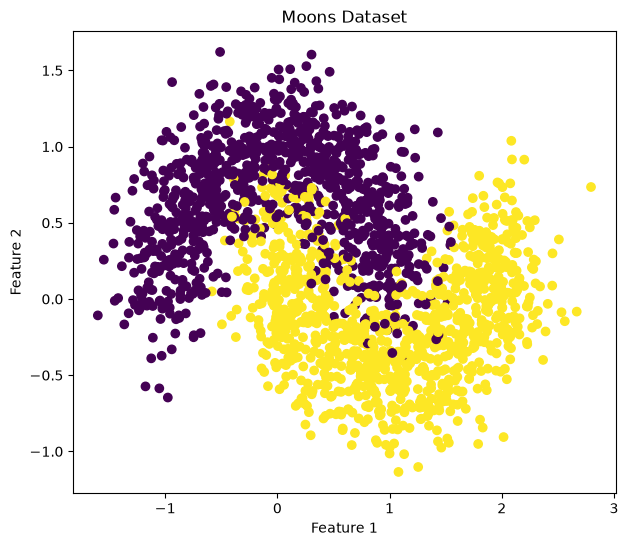

In [3]:
from sklearn.datasets import make_moons,make_circles,make_classification,make_blobs

X ,y = make_moons(
    n_samples = 2000,
    noise = 0.25,
    random_state = 182
)

plt.figure(figsize = (7,6))
plt.scatter(X[:,0],X[:,1],c = y)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Moons Dataset")
plt.show()

In [4]:
X_train,X_test,Y_train,Y_test = train_test_split(X,y,test_size = 0.2,random_state = 42)

print(X_train.shape)
print(X_test.shape)
print(Y_train.shape)
print(Y_test.shape)

(1600, 2)
(400, 2)
(1600,)
(400,)


Train Done
Test Done
Accuracy :  0.9
Confusion Matrix : 
 [[172  21]
 [ 19 188]]
Classification Report : 
               precision    recall  f1-score   support

           0       0.90      0.89      0.90       193
           1       0.90      0.91      0.90       207

    accuracy                           0.90       400
   macro avg       0.90      0.90      0.90       400
weighted avg       0.90      0.90      0.90       400

ROC AUC Score :  0.8997021351155166


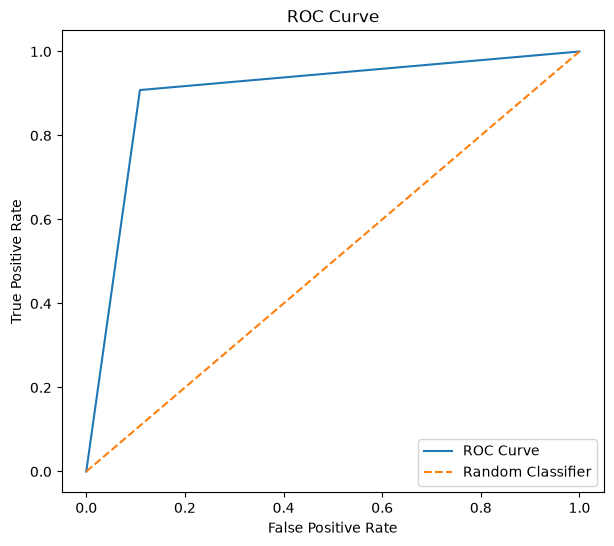

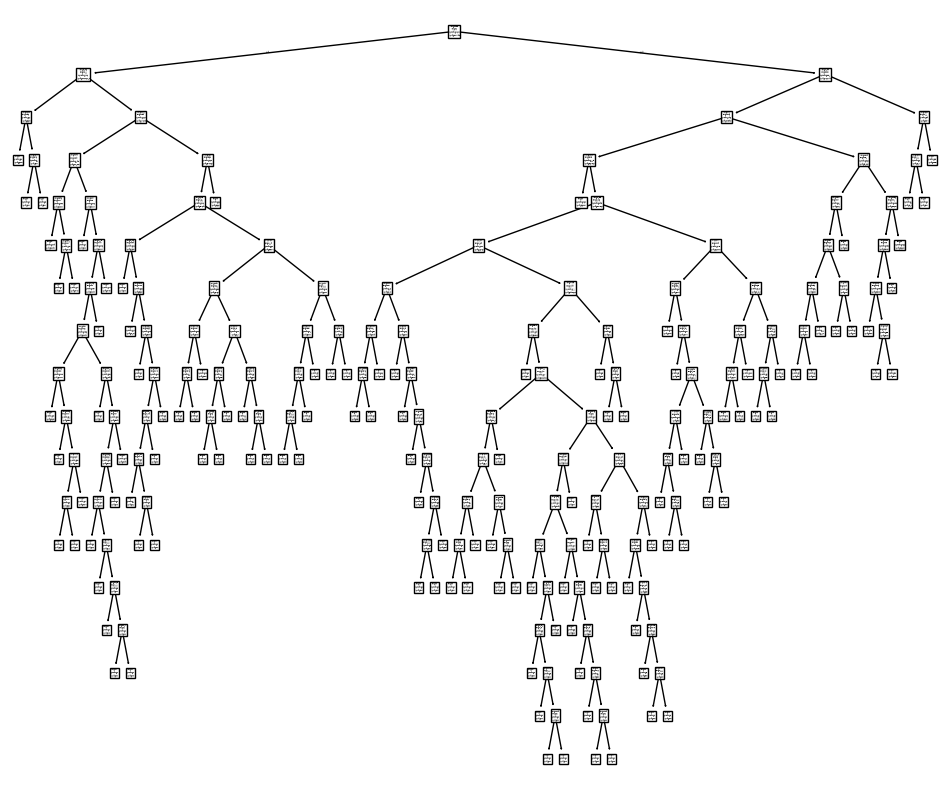

In [12]:
#Decision Tree
dt_model = DecisionTreeClassifier()
evaluate_model(dt_model,X_train,X_test,Y_train,Y_test)
#print the model
from sklearn.tree import plot_tree
plt.figure(figsize=(12,10))
plot_tree(dt_model)
plt.show()

Train Done
Test Done
Accuracy :  0.89
Confusion Matrix : 
 [[174  19]
 [ 25 182]]
Classification Report : 
               precision    recall  f1-score   support

           0       0.87      0.90      0.89       193
           1       0.91      0.88      0.89       207

    accuracy                           0.89       400
   macro avg       0.89      0.89      0.89       400
weighted avg       0.89      0.89      0.89       400

ROC AUC Score :  0.9410653049986233


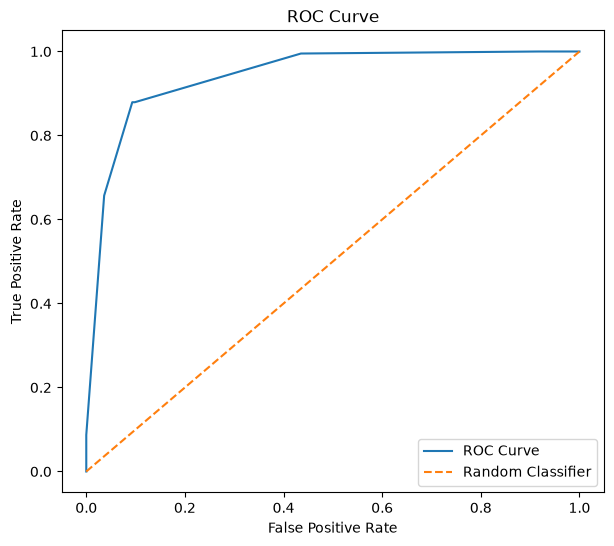

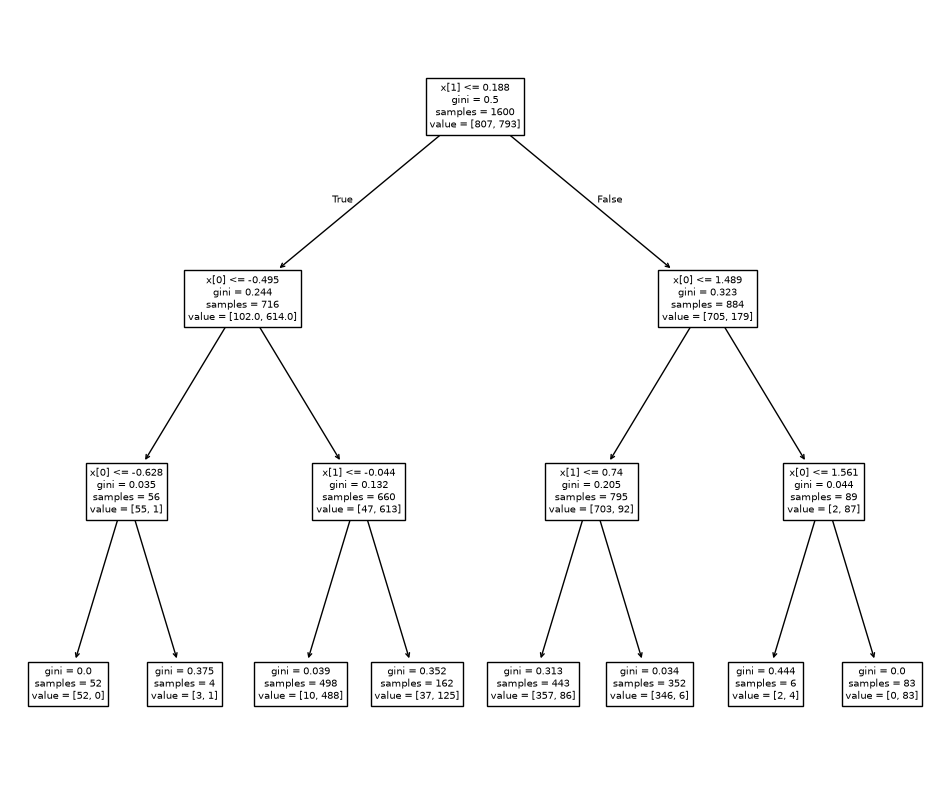

In [13]:
#Decision Tree
dt_model = DecisionTreeClassifier(max_depth=3)
evaluate_model(dt_model,X_train,X_test,Y_train,Y_test)
#print the model
from sklearn.tree import plot_tree
plt.figure(figsize=(12,10))
plot_tree(dt_model)
plt.show()

Train Done
Test Done
Accuracy :  0.8925
Confusion Matrix : 
 [[175  18]
 [ 25 182]]
Classification Report : 
               precision    recall  f1-score   support

           0       0.88      0.91      0.89       193
           1       0.91      0.88      0.89       207

    accuracy                           0.89       400
   macro avg       0.89      0.89      0.89       400
weighted avg       0.89      0.89      0.89       400

ROC AUC Score :  0.9640684838927686


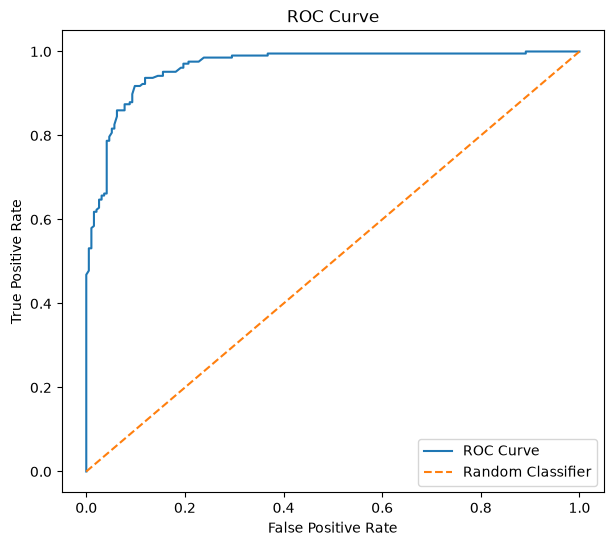

In [14]:
#Random Forest
rf_model = RandomForestClassifier(
    n_estimators=50,
    max_depth=3,
    bootstrap=True,
    random_state=42
)
evaluate_model(rf_model,X_train,X_test,Y_train,Y_test)




Train Done
Test Done
Accuracy :  0.8975
Confusion Matrix : 
 [[174  19]
 [ 22 185]]
Classification Report : 
               precision    recall  f1-score   support

           0       0.89      0.90      0.89       193
           1       0.91      0.89      0.90       207

    accuracy                           0.90       400
   macro avg       0.90      0.90      0.90       400
weighted avg       0.90      0.90      0.90       400

ROC AUC Score :  0.9583990388225576


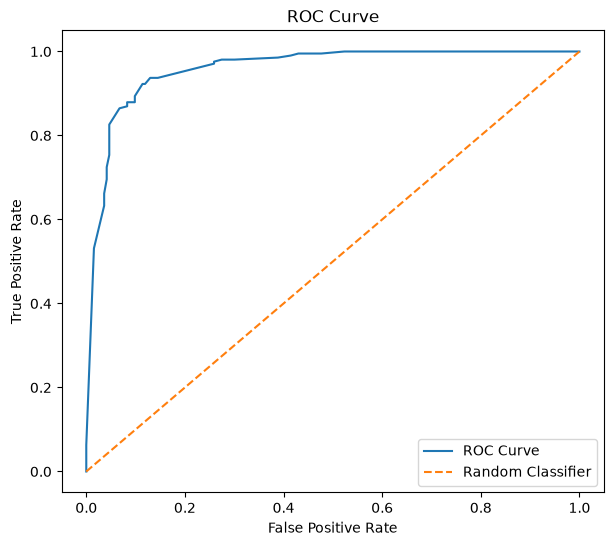

In [16]:
#Bagging Methods
bagging_model = BaggingClassifier(
    estimator = DecisionTreeClassifier(max_depth = 3),
    n_estimators = 50,
    bootstrap = True,
    random_state = 42
)

evaluate_model(bagging_model,X_train,X_test,Y_train,Y_test)

Train Done
Test Done
Accuracy :  0.93
Confusion Matrix : 
 [[176  17]
 [ 11 196]]
Classification Report : 
               precision    recall  f1-score   support

           0       0.94      0.91      0.93       193
           1       0.92      0.95      0.93       207

    accuracy                           0.93       400
   macro avg       0.93      0.93      0.93       400
weighted avg       0.93      0.93      0.93       400

ROC AUC Score :  0.98395534529799


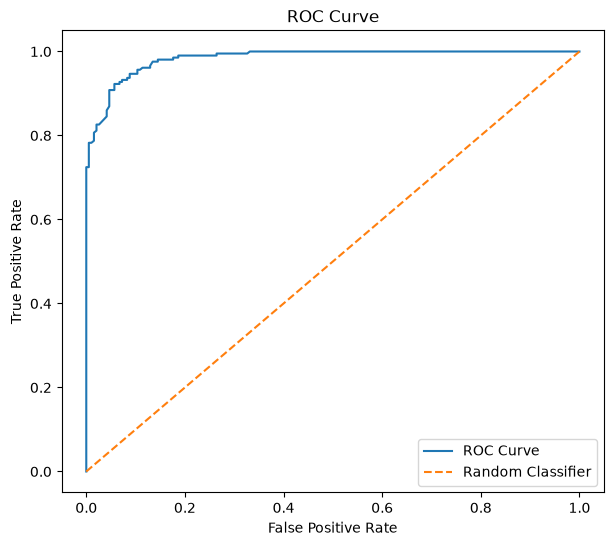

In [17]:
#Adaboost
ada_model = AdaBoostClassifier(
    estimator = DecisionTreeClassifier(max_depth = 3),
    n_estimators = 50,
    random_state = 42
)

evaluate_model(ada_model,X_train,X_test,Y_train,Y_test)

Train Done
Test Done
Accuracy :  0.93
Confusion Matrix : 
 [[180  13]
 [ 15 192]]
Classification Report : 
               precision    recall  f1-score   support

           0       0.92      0.93      0.93       193
           1       0.94      0.93      0.93       207

    accuracy                           0.93       400
   macro avg       0.93      0.93      0.93       400
weighted avg       0.93      0.93      0.93       400

ROC AUC Score :  0.9807389051588195


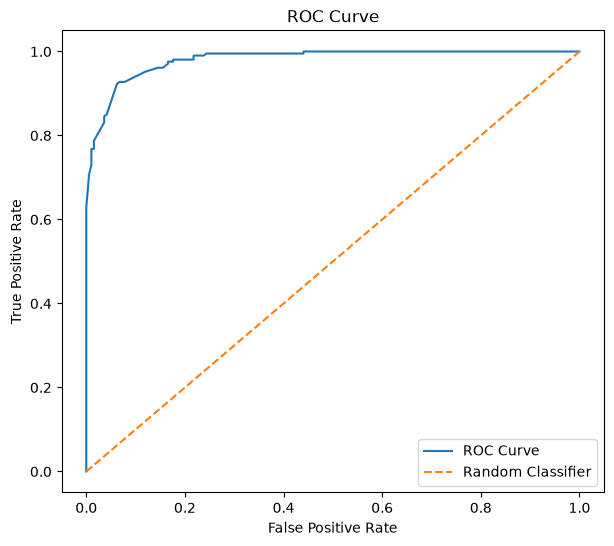

In [18]:
ada_model = AdaBoostClassifier(
    estimator = DecisionTreeClassifier(max_depth = 1),
    n_estimators = 50,
    random_state = 42
)

evaluate_model(ada_model,X_train,X_test,Y_train,Y_test)

In [19]:
print("Weights of the first 10 estimators")
print(ada_model.estimator_weights_[:10])

Weights of the first 10 estimators
[1.54627448 1.0327396  1.2224392  0.83984042 0.590756   0.64469499
 0.58302571 0.6002277  0.4923768  0.66457104]


In [20]:
print(ada_model.estimator_errors_[:10])

[0.175625   0.26255332 0.22750748 0.3015684  0.35646141 0.344186
 0.35823668 0.3542916  0.37933381 0.33971354]


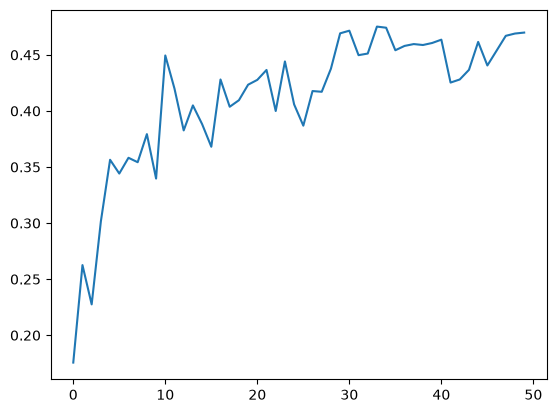

In [21]:
plt.plot(ada_model.estimator_errors_)

Train Done
Test Done
Accuracy :  0.9275
Confusion Matrix : 
 [[180  13]
 [ 16 191]]
Classification Report : 
               precision    recall  f1-score   support

           0       0.92      0.93      0.93       193
           1       0.94      0.92      0.93       207

    accuracy                           0.93       400
   macro avg       0.93      0.93      0.93       400
weighted avg       0.93      0.93      0.93       400

ROC AUC Score :  0.9788240594728542


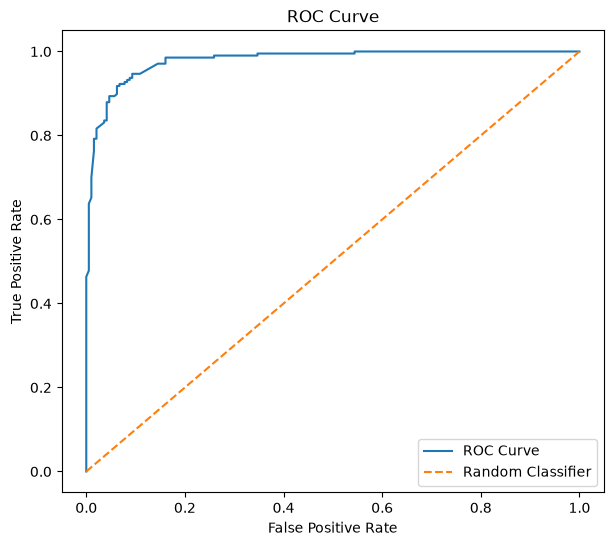

In [22]:
#Gradient Boosting
grad_boost_model = GradientBoostingClassifier(
    n_estimators=50,
    learning_rate=0.1,
    random_state=42,
    
)
evaluate_model(grad_boost_model,X_train,X_test,Y_train,Y_test)

Train Done
Test Done
Accuracy :  0.9275
Confusion Matrix : 
 [[179  14]
 [ 15 192]]
Classification Report : 
               precision    recall  f1-score   support

           0       0.92      0.93      0.93       193
           1       0.93      0.93      0.93       207

    accuracy                           0.93       400
   macro avg       0.93      0.93      0.93       400
weighted avg       0.93      0.93      0.93       400

ROC AUC Score :  0.98105178844084


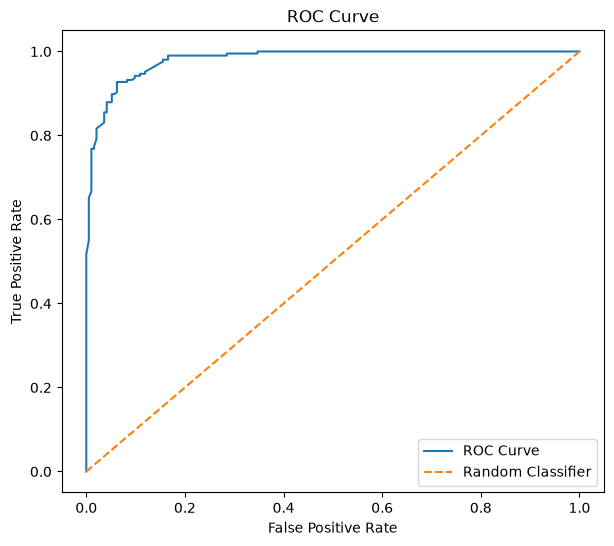

In [23]:
#XGBOOST
xgb_model = XGBClassifier(
    n_estimators = 50,
    learning_rate = 0.1,
    max_depth = 3,
    random_state = 42
)

evaluate_model(xgb_model,X_train,X_test,Y_train,Y_test)

In [24]:
# Light GBM

lgbm_model = LGBMClassifier(
    n_estimators = 50,
    learning_rate = 0.1,
    max_depth = 3,
    random_state = 42
)

evaluate_model(lgbm_model,X_train,X_test,Y_train,Y_test)

NameError: name 'LGBMClassifier' is not defined